# Parte 2: Auditoria do Modelo em Produção (Modelo A)

---

## Introdução

O objetivo desta etapa é auditar o desempenho do classificador atualmente em produção (Modelo A). A avaliação não deve se limitar a estimativas pontuais, mas quantificar a incerteza estatística das predições e identificar modos sistemáticos de falha que impactem a operação da Central 1746.

A análise é dividida em duas etapas:
1. **Desempenho com Incerteza:** Cálculo de métricas globais com Intervalos de Confiança.
2. **Onde o Modelo Falha?:** Inspeção de performance por categoria e matriz de confusão.

---

## Etapa 1: Desempenho com Incerteza

### Escolha de Métricas
Conforme diagnosticado na Fase 1, o dataset apresenta desbalanceamento (a classe majoritária possui ~23% das amostras; a minoritária, ~4.5%). Logo:
* A Acurácia Global será reportada, mas não será o critério principal, pois tende a superestimar o desempenho ao favorecer as classes majoritárias.
* Adotaremos o F1-Score (Macro) como métrica principal para o desempenho global, que calcula a média harmônica entre Precision e Recall para cada classe independentemente do seu volume, penalizando o modelo caso ele negligencie as categorias minoritárias.

### Método de Incerteza
Para quantificar a incerteza, utilizaremos Bootstrapping não-paramétrico, que consiste em reamostrar o conjunto de testes com reposição ($N=1000$ iterações) para construir uma distribuição empírica das métricas, permitindo o cálculo de Intervalos de Confiança (IC) a 95%.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
from pathlib import Path

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregamento dos dados
DATA_PATH = Path("../dados/chamados_com_predicoes.csv")
np.random.seed(42)

### 1.1. Síntese do Desempenho Global (Modelo A)

Aqui, fazemos a execução do Bootstrapping (N=1000) para um intervalo de confiança de 95%

In [8]:
df = pd.read_csv(DATA_PATH)

# Arrays de predição e target
y_true = df['categoria_real'].values
y_pred_a = df['pred_modelo_a'].values

def calcular_metricas(y_true, y_pred):
    """Calcula métricas pontuais para o modelo."""
    return {
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precision (Macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

def bootstrap_confidence_intervals(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """Gera intervalos de confiança usando Bootstrapping não-paramétrico."""
    estatisticas = {k: [] for k in calcular_metricas(y_true, y_pred).keys()}
    n_size = len(y_true)
    
    # Processo de reamostragem
    for _ in range(n_iterations):
        idx = resample(np.arange(n_size), n_samples=n_size)
        metrics = calcular_metricas(y_true[idx], y_pred[idx])
        for key, value in metrics.items():
            estatisticas[key].append(value)
            
    # Cálculo dos percentis para o IC
    p_lower = ((1.0 - alpha) / 2.0) * 100
    p_upper = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    resultados_ic = {}
    metricas_pontuais = calcular_metricas(y_true, y_pred)
    
    for key in estatisticas.keys():
        lower = np.percentile(estatisticas[key], p_lower)
        upper = np.percentile(estatisticas[key], p_upper)
        resultados_ic[key] = {
            'Estimativa Pontual': metricas_pontuais[key],
            'IC Inferior (95%)': lower,
            'IC Superior (95%)': upper
        }
        
    return pd.DataFrame(resultados_ic).T

df_metricas_globais = bootstrap_confidence_intervals(y_true, y_pred_a)
print("=== Desempenho Global do Modelo A (com IC 95%) ===")
display(df_metricas_globais.round(4))

=== Desempenho Global do Modelo A (com IC 95%) ===


,Estimativa Pontual,IC Inferior (95%),IC Superior (95%)
Acurácia,0.7728,0.7614,0.7840
Precision (Macro),0.7743,0.7621,0.7873
Recall (Macro),0.7710,0.7580,0.7836
F1-Score (Macro),0.7704,0.7577,0.7826


### Resultados

* **Estabilidade das Métricas:** O modelo apresenta um F1-Score Macro pontual de 0.7704. O intervalo de confiança a 95% (0.7577 a 0.7826) indica que a performance é estatisticamente estável.
* **Equilíbrio Precision-Recall:** A proximidade entre a Precision e o Recall sugere que, globalmente, o modelo não sofre de vieses extremos de superpredição (excesso de falsos positivos) ou subpredição (excesso de falsos negativos).

### 1.2. Incerteza Granular: Intervalos de Confiança por Categoria

A estimativa global mascara a variabilidade inerente às classes minoritárias. Pela Lei dos Grandes Números, categorias com menor suporte amostral (como `sinalizacao`) tendem a apresentar maior variância em suas métricas preditivas. 

Para analisar esse risco, aplicamos o mesmo processo de Bootstrapping e analisamos para cada classe. A representação visual e tabular dos Intervalos de Confiança a 95% permitirá diagnosticar em quais categorias o Modelo A apresenta maior instabilidade na sua predição.

In [9]:
from sklearn.metrics import precision_recall_fscore_support

def bootstrap_metricas_por_classe(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula ICs de 95% para Precision, Recall e F1-Score de forma isolada para cada categoria.
    """
    classes = np.unique(y_true)
    # Estrutura para armazenar as distribuições empíricas
    stats = {c: {'precision': [], 'recall': [], 'f1': []} for c in classes}
    n_size = len(y_true)

    # Reamostragem
    for _ in range(n_iterations):
        idx = resample(np.arange(n_size), n_samples=n_size)
        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        
        p, r, f, _ = precision_recall_fscore_support(
            y_true_b, y_pred_b, labels=classes, zero_division=0
        )
        
        for i, c in enumerate(classes):
            stats[c]['precision'].append(p[i])
            stats[c]['recall'].append(r[i])
            stats[c]['f1'].append(f[i])
            
    # Definição dos limites dos percentis
    p_lower = ((1.0 - alpha) / 2.0) * 100
    p_upper = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    # Estimativas pontuais
    p_point, r_point, f_point, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=classes, zero_division=0
    )
    
    resultados = []
    for i, c in enumerate(classes):
        resultados.append({
            'Categoria': c,
            'F1-Score (IC 95%)': f"{f_point[i]:.4f} [{np.percentile(stats[c]['f1'], p_lower):.4f} - {np.percentile(stats[c]['f1'], p_upper):.4f}]",
            'Precision (IC 95%)': f"{p_point[i]:.4f} [{np.percentile(stats[c]['precision'], p_lower):.4f} - {np.percentile(stats[c]['precision'], p_upper):.4f}]",
            'Recall (IC 95%)': f"{r_point[i]:.4f} [{np.percentile(stats[c]['recall'], p_lower):.4f} - {np.percentile(stats[c]['recall'], p_upper):.4f}]"
        })
        
    return pd.DataFrame(resultados).set_index('Categoria')

# Execução da análise de incerteza por classe
df_ic_classes = bootstrap_metricas_por_classe(y_true, y_pred_a)
print("=== Intervalos de Confiança (95%) por Categoria - Modelo A ===")
display(df_ic_classes)

=== Intervalos de Confiança (95%) por Categoria - Modelo A ===


,F1-Score (IC 95%),Precision (IC 95%),Recall (IC 95%)
Categoria,,,
barulho_perturbacao,0.7878 [0.7553 - 0.8181],0.8010 [0.7619 - 0.8401],0.7750 [0.7341 - 0.8170]
buraco_via,0.7328 [0.7095 - 0.7534],0.6643 [0.6361 - 0.6919],0.8172 [0.7908 - 0.8412]
coleta_lixo,0.8105 [0.7900 - 0.8304],0.8145 [0.7863 - 0.8400],0.8065 [0.7793 - 0.8321]
esgoto_vazamento,0.6382 [0.6033 - 0.6684],0.7123 [0.6737 - 0.7495],0.5781 [0.5391 - 0.6132]
estacionamento_irregular,0.8131 [0.7855 - 0.8419],0.8004 [0.7657 - 0.8382],0.8261 [0.7903 - 0.8584]
iluminacao_publica,0.8236 [0.8057 - 0.8412],0.8571 [0.8369 - 0.8765],0.7927 [0.7686 - 0.8159]
poda_arvore,0.7889 [0.7576 - 0.8159],0.8032 [0.7673 - 0.8387],0.7751 [0.7340 - 0.8124]
sinalizacao,0.7686 [0.7212 - 0.8087],0.7418 [0.6823 - 0.7935],0.7974 [0.7474 - 0.8515]


#### Resultados

A partir dos resultados da tabela acima, podemos perceber três características de desempenho:

1. **Suporte Amostral e Variância:** A categoria `sinalizacao` (menor volume de dados) apresenta a maior instabilidade estatística, o que é esperado. O IC para o F1-Score tem uma amplitude superior a 8 pontos percentuais. No contrário, a classe majoritária `iluminacao_publica` apresenta uma variação menor, de aproximadamente 4 pontos. A escassez de dados reduz diretamente a confiabilidade em produção.

2. **Maior Déficit (Esgoto/Vazamento):** A categoria `esgoto_vazamento` é o principal ponto de falha do Modelo A. O limite superior do seu IC de Recall (~ 0.61) demonstra que, mesmo no melhor cenário estatístico estimado, o sistema é cego para quase 40% dos problemas reais de saneamento. 

3. **Trade-off Desbalanceado (Sensibilidade excessiva a buracos):** Em contrapartida ao déficit de esgoto, a categoria `buraco_via` exibe um comportamento inverso: possui o menor limite inferior de Precision (~0.64), mas um Recall alto [~0.79 - ~0.84], onde vemos que o modelo A tem uma tendência a super-classificar problemas como "buraco na via", com alto volume de Falsos Positivos.

### 1.3. Análise de Confiança do Modelo

Algo importante de se analisar, também, é a métrica `conf_modelo_a`, que reflete a probabilidade estimada pelo modelo de que sua predição está correta. Nesse contexto, sistemas de IA frequentemente podem utilizar esse limiar de confiança para automação (ex: "se confiança > 0.90, encaminhe a equipe sem triagem humana"). Para validar se o modelo pode operar de forma autônoma e segura, analisamos sua Calibração de Probabilidades

* **O conceito:** Um modelo bem calibrado deve acertar 90% das vezes em que declara 90% de confiança.
* **Expected Calibration Error (ECE):** Métrica que calcula a divergência média entre a confiança declarada e a acurácia empírica. Valores menores indicam melhor calibração.
* **Superconfiança (Overconfidence):** Risco grave onde o modelo erra categoricamente, mas declara alta certeza matemática, contornando travas de segurança da aplicação, dificultando chamada de triagem humana.

=== Expected Calibration Error (ECE) Global - Modelo A ===: 0.1516


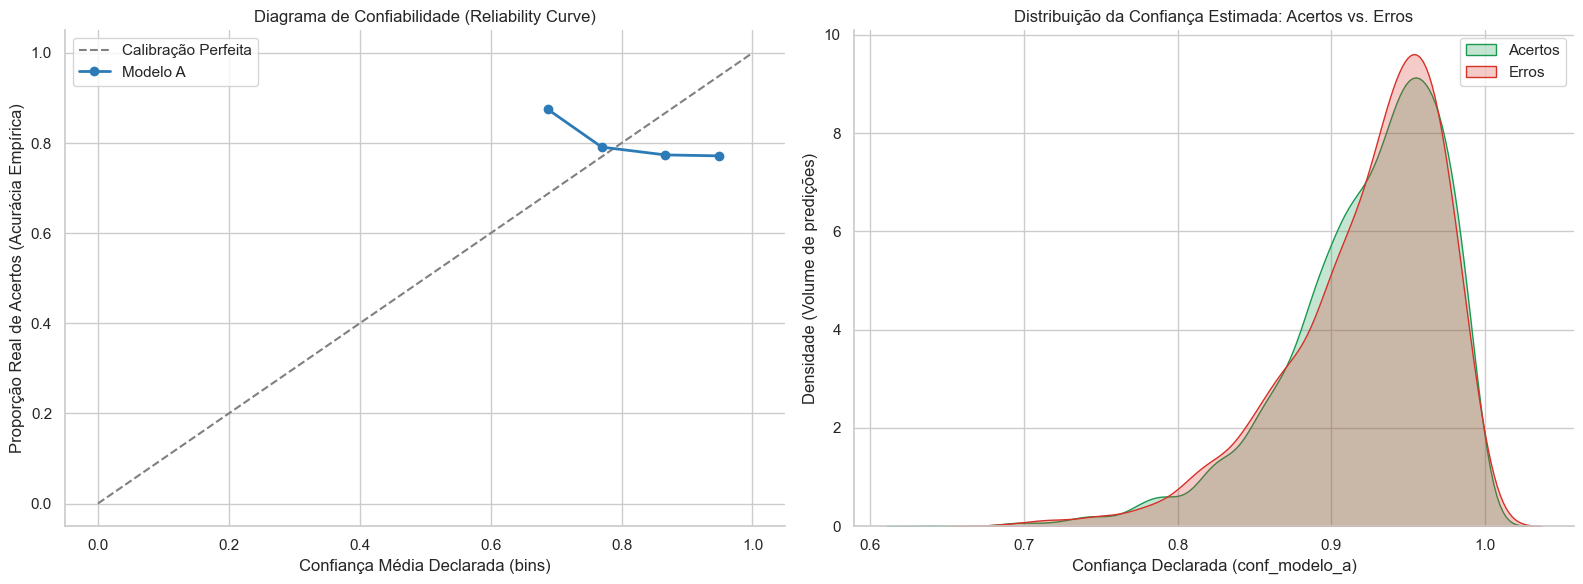

In [10]:
from sklearn.calibration import calibration_curve

# verificamos se a confiança da classe predita corresponde à probabilidade real de acerto.
acertos = (y_true == y_pred_a).astype(int)
confianca = df['conf_modelo_a'].values

# Curva de Calibração (Reliability Curve)
n_bins = 10
prob_verdadeira, prob_prevista = calibration_curve(acertos, confianca, n_bins=n_bins, strategy='uniform')

# Cálculo do Expected Calibration Error (ECE)
ece = 0
total_samples = len(confianca)
bin_edges = np.linspace(0, 1, n_bins + 1)

for i in range(n_bins):
    # Separação dos dados em decis de confiança
    if i == n_bins - 1:
        bin_mask = (confianca >= bin_edges[i]) & (confianca <= bin_edges[i+1])
    else:
        bin_mask = (confianca >= bin_edges[i]) & (confianca < bin_edges[i+1])
    
    bin_samples = bin_mask.sum()
    if bin_samples > 0:
        bin_acc = acertos[bin_mask].mean()
        bin_conf = confianca[bin_mask].mean()
        # ECE pondera o erro pelo volume de amostras na lixeira
        ece += (bin_samples / total_samples) * np.abs(bin_acc - bin_conf)

print(f"=== Expected Calibration Error (ECE) Global - Modelo A ===: {ece:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagrama de Confiabilidade
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração Perfeita')
axes[0].plot(prob_prevista, prob_verdadeira, marker='o', linewidth=2, color='#2c7bb6', label='Modelo A')
axes[0].set_title('Diagrama de Confiabilidade (Reliability Curve)')
axes[0].set_xlabel('Confiança Média Declarada (bins)')
axes[0].set_ylabel('Proporção Real de Acertos (Acurácia Empírica)')
axes[0].legend()

# Distribuição de Confiança - Acertos vs Erros
sns.kdeplot(confianca[acertos == 1], ax=axes[1], fill=True, color='#1a9850', label='Acertos')
sns.kdeplot(confianca[acertos == 0], ax=axes[1], fill=True, color='#d73027', label='Erros')
axes[1].set_title('Distribuição da Confiança Estimada: Acertos vs. Erros')
axes[1].set_xlabel('Confiança Declarada (conf_modelo_a)')
axes[1].set_ylabel('Densidade (Volume de predições)')
axes[1].legend()

# Retirando as bordas superiores e direitas para manter um design limpo
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Resultado Ruim -> Superconfiança

A análise da métrica `conf_modelo_a` revela que o Modelo A é superconfiante, o que compromete o uso da sua probabilidade estimada para regras automáticas de triagem. O Expected Calibration Error (ECE) global de ~0.15 quantifica essa distorção estatística, mas a análise visual expõe o verdadeiro gargalo:

1. **Curva de Confiabilidade Descendo:** No diagrama da esquerda, a curva do Modelo A segue a ordem contrária de um modelo ideal. O algorítmo mantém confiança muito alta na maioria das vezes, e nos momentos de mais alta confiança, tende a errar mais. 
2. **Incerteza (Acertos vs. Erros):** Como evidenciado no gráfico da direita, as curvas de acertos (verde) e erros (vermelha) sofrem forte sobreposição na extremidade de alta probabilidade. O modelo não demonstra degradação de confiança quando está diante de dados confusos; ele erra com o mesmo grau de certeza matemática com que acerta.

#### Risco
A consequência direta disso é a impossibilidade de criar regras do tipo *Straight-Through Processing* (STP). Se a IplanRio configurar a Central 1746 para despachar automaticamente qualquer chamado com confiança $> 0.90$, uma parcela inaceitável de predições incorretas passará direto pela triagem. O Modelo A, portanto, é inadequado para automação total e exige supervisão contínua de atendentes humanos

## Etapa 2: Onde o Modelo Falha? 

As métricas globais fornecem um panorama da confiabilidade do sistema, mas ofuscam variações de desempenho entre diferentes tipos de serviços. Em problemas multiclasse no setor público, nem todo erro possui o mesmo custo operacional.

### 2.1 Análise por Categoria e Matriz de Confusão
Nesta etapa, a investigação desce ao nível das classes para identificar modos de falha estruturais:
1. **Desempenho por Categoria:** Identificação das classes com os menores índices de Recall (muitos Falsos Negativos) e Precision (muitos Falsos Positivos).
2. **Matriz de Confusão:** Mapeamento visual das trocas (erros de tipificação). O objetivo é verificar se o modelo confunde sistematicamente categorias semanticamente próximas (ex: `buraco_rua` vs `pavimentacao`), o que pode indicar problemas de ontologia nos dados, e não necessariamente incapacidade matemática do algoritmo.

=== Relatório de Classificação por Categoria (Modelo A) ===


,precision,recall,f1-score,support
iluminacao_publica,0.857,0.793,0.824,1143.0
estacionamento_irregular,0.800,0.826,0.813,437.0
coleta_lixo,0.815,0.806,0.810,806.0
poda_arvore,0.803,0.775,0.789,458.0
barulho_perturbacao,0.801,0.775,0.788,400.0
sinalizacao,0.742,0.797,0.769,227.0
buraco_via,0.664,0.817,0.733,908.0
esgoto_vazamento,0.712,0.578,0.638,621.0


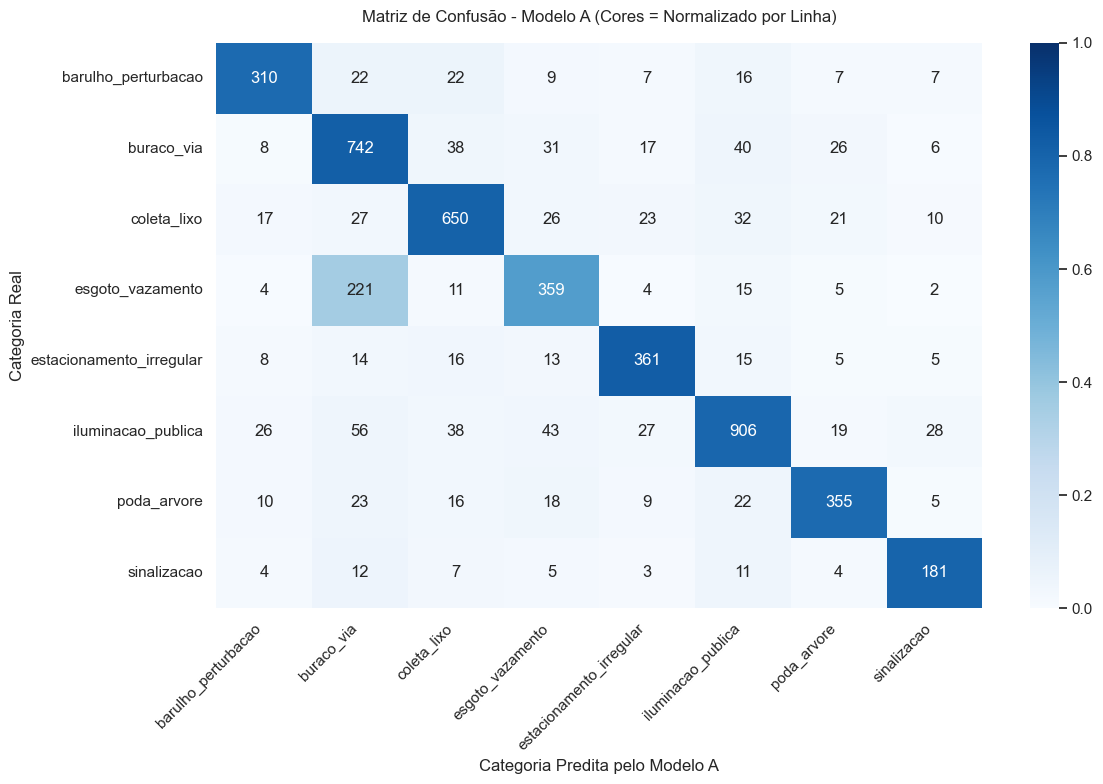

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Relatório de Classificação por Categoria (Modelo A) ===")
report = classification_report(y_true, y_pred_a, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()
df_report_classes = df_report.iloc[:-3, :].sort_values(by='f1-score', ascending=False)
display(df_report_classes.round(3))

categorias = sorted(list(set(y_true)))
cm = confusion_matrix(y_true, y_pred_a, labels=categorias)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    cm_normalized, 
    annot=cm,
    fmt='d', 
    cmap='Blues',
    xticklabels=categorias, 
    yticklabels=categorias,
    vmin=0, vmax=1
)
plt.title('Matriz de Confusão - Modelo A (Cores = Normalizado por Linha)', pad=15)
plt.ylabel('Categoria Real')
plt.xlabel('Categoria Predita pelo Modelo A')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Resultados

* A categoria `esgoto_vazamento` possui o pior desempenho isolado, com um Recall de apenas ~0.58. Logo, mais de 42% dos chamados reais de esgoto/vazamento não são detectados.
* A matriz de confusão aponta o destino desse erro: uma troca para a categoria `buraco_via` (que, por conta disso, tem sua Precision derrubada para ~0.66).

**Hipótese Causal (Sobreposição Semântica):**
Em chamados abertos por cidadãos, problemas hídricos frequentemente afetam o asfalto. Relatos contendo frases como *"abriu uma cratera jorrando água na rua"* carregam ambiguidade. O modelo atual demonstra incapacidade de diferenciar a sintaxe de um problema estrutural (buraco) de um problema de saneamento (vazamento) quando ocorrem no mesmo contexto.

**Impacto Prático para a Prefeitura:**
Erros de classificação entre essas duas categorias possuem alto custo logístico. Encaminhar um chamado de vazamento de esgoto para uma equipe responsável por essa correção de infraestrutura resulta em deslocamento inútil de maquinário de pavimentação, atraso na resolução do problema original e retrabalho de triagem para repassar a demanda à concessionária de água/esgoto.

### 2.2. Análise de Erros por Subgrupos

Para responder se o desempenho do Modelo A é homogêneo, é necessário investigar se a taxa de erro flutua significativamente dependendo do contexto do chamado (canal, geografia, tempo ou complexidade do texto). 

A abordagem estatística adotada consiste em:
1. **Binarização do Desempenho:** Criação de uma variável indicadora de erro (`errou = 1` se predição $\neq$ target, `0` caso contrário).
2. **Discretização:** Transformação do tamanho do texto contínuo em quartis para viabilizar a análise categórica.
3. **Teste de Independência (Qui-Quadrado):** Aplicação do Teste Qui-Quadrado de Pearson cruzando cada subgrupo com a variável de erro. 
    * **Hipótese Nula ($H_0$):** A taxa de erro é estatisticamente independente do subgrupo (Desempenho Homogêneo).
    * **Hipótese Alternativa ($H_1$):** A taxa de erro varia conforme a categoria analisada, indicando viés (Bias) do modelo.

=== Teste de Independência de Erros (Qui-Quadrado) ===


,p-valor,Desempenho Homogêneo?
Subgrupo,,
Canal de Entrada,3.679598e-01,Sim
Tamanho do Texto (Quartis),2.168314e-75,Não (Modelo Enviesado)
Dia da Semana,7.953138e-01,Sim
Bairro,8.656215e-01,Sim


C:\Users\João Gabriel\AppData\Local\Temp\ipykernel_10304\3608104274.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_erro = df.groupby(feat)['errou'].mean().sort_values(ascending=False) * 100


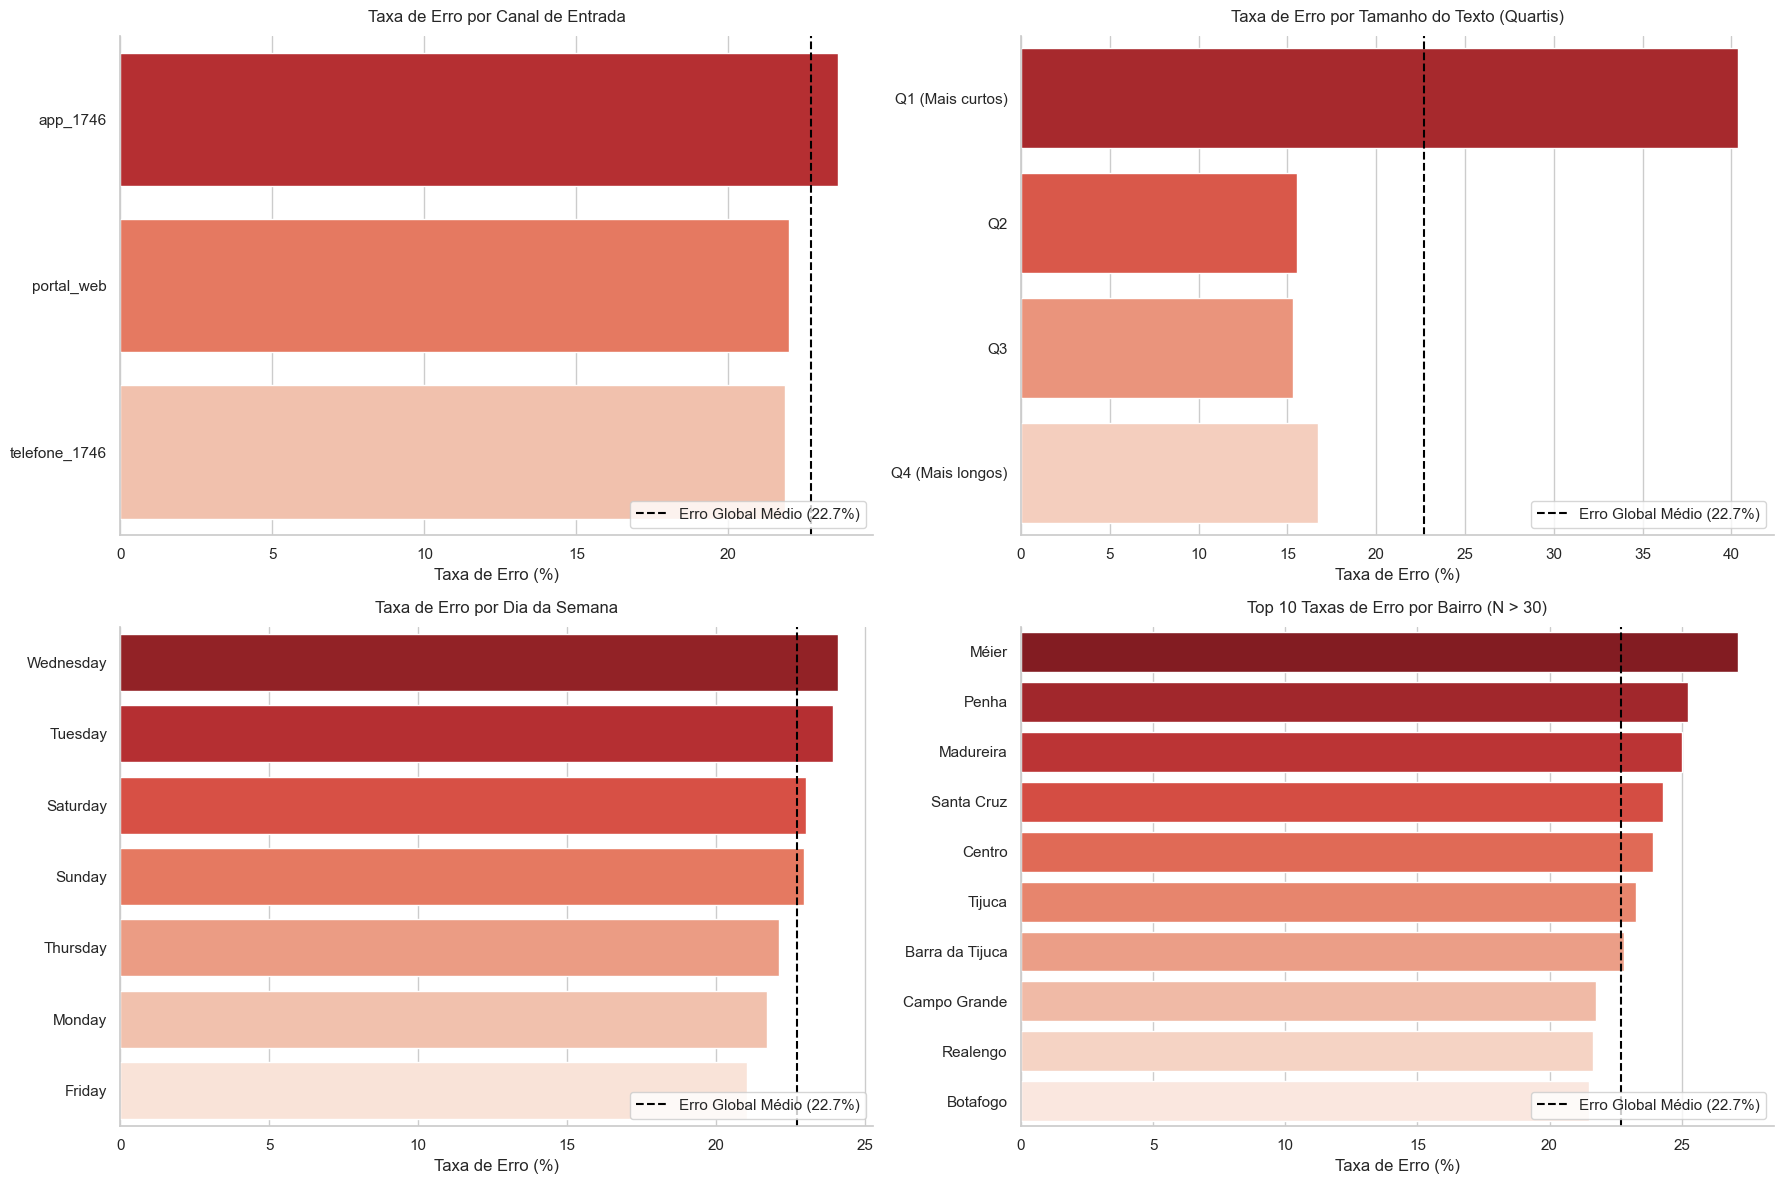

In [12]:
from scipy.stats import chi2_contingency

# Variável alvo de erro
df['errou'] = (df['categoria_real'] != df['pred_modelo_a']).astype(int)

# Categorizando o tamanho do texto em quartis para análise
df['data_abertura'] = pd.to_datetime(df['data_abertura'])

df['tamanho_texto_quartil'] = pd.qcut(
    df['texto'].apply(lambda x: len(str(x).split())), 
    q=4, 
    labels=['Q1 (Mais curtos)', 'Q2', 'Q3', 'Q4 (Mais longos)']
)

df['dia_semana'] = df['data_abertura'].dt.day_name()

features_analise = {
    'canal': 'Canal de Entrada', 
    'tamanho_texto_quartil': 'Tamanho do Texto (Quartis)', 
    'dia_semana': 'Dia da Semana', 
    'bairro': 'Bairro'
}

# Teste Qui-Quadrado
resultados_homogeneidade = []

for feat, label in features_analise.items():
    tabela = pd.crosstab(df[feat], df['errou'])
    chi2, p_val, dof, ex = chi2_contingency(tabela)
    
    resultados_homogeneidade.append({
        'Subgrupo': label,
        'p-valor': p_val,
        'Desempenho Homogêneo?': 'Sim' if p_val >= 0.05 else 'Não (Modelo Enviesado)'
    })

print("=== Teste de Independência de Erros (Qui-Quadrado) ===")
display(pd.DataFrame(resultados_homogeneidade).set_index('Subgrupo'))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (feat, label) in enumerate(features_analise.items()):
    # Calcula a taxa de erro média (%)
    taxa_erro = df.groupby(feat)['errou'].mean().sort_values(ascending=False) * 100
    
    # Se for bairro, limitamos aos 10 com maior taxa de erro (suporte > 30 chamados para evitar ruído)
    if feat == 'bairro':
        bairros_validos = df['bairro'].value_counts()[df['bairro'].value_counts() > 30].index
        taxa_erro = df[df['bairro'].isin(bairros_validos)].groupby(feat)['errou'].mean().sort_values(ascending=False) * 100
        taxa_erro = taxa_erro.head(10)
        titulo = f'Top 10 Taxas de Erro por {label} (N > 30)'
    else:
        titulo = f'Taxa de Erro por {label}'

    # Plot
    sns.barplot(x=taxa_erro.values, y=taxa_erro.index, ax=axes[i], palette='Reds_r', hue=taxa_erro.index, legend=False)
    axes[i].set_title(titulo, pad=10)
    axes[i].set_xlabel('Taxa de Erro (%)')
    axes[i].set_ylabel('')
    
    # Linha de referência: Erro Global do Modelo
    erro_global = df['errou'].mean() * 100
    axes[i].axvline(erro_global, color='black', linestyle='--', label=f'Erro Global Médio ({erro_global:.1f}%)')
    axes[i].legend(loc='lower right')
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Resultados

A aplicação do Teste de Independência Qui-Quadrado sobre a variável de erro revela pontos importantes sobre a estabilidade do Modelo A em diferentes contextos operacionais:

**1. Ausência de Viés Demográfico e Tecnológico:**
* Os altos p-valores para `bairro` (0.86), `dia_semana` (0.79) e `canal` (0.36) confirmam que o modelo apresenta desempenho homogêneo nesses recortes. 
* *Impacto Prático:* O classificador não penaliza cidadãos de regiões específicas e mantém a estabilidade independentemente da plataforma de uso (App, Web, Telefone).

**2. A Falha Estrutural: Déficit de Contexto em Textos Curtos:**
* O teste rejeita fortemente a hipótese de homogeneidade em relação ao comprimento do texto ($p < 0.05$, na ordem de $10^{-75}$). A inspeção visual demonstra que a taxa de erro é bem maior no primeiro quartil (Q1), composto pelos chamados com texto mais curtos.
* *Hipótese Causal:* Textos muito curtos sofrem de esparsidade de features. A ausência de contexto semântico suficiente impede o algoritmo de desambiguar categorias sobrepostas (como buraco vs. vazamento de esgoto, já diagnosticados na matriz de confusão).

**3. Impacto Prático e Recomendação de Mitigação:**
* Se a Prefeitura mantiver o Modelo A, chamados extremamente curtos (Q1) não devem ser encaminhados via automação (*Straight-Through Processing*), sob pena de alto índice de roteamento incorreto.
* *Mitigação Sugerida:* A IplanRio pode atuar no produto (UX/UI), implementando validações no App 1746 que exijam um limite mínimo de caracteres e encorajem o cidadão a fornecer mais detalhes. Alternativamente, chamados do Q1 devem ser compulsoriamente enviados para a fila de triagem humana.